<a href="https://colab.research.google.com/github/antonDinkov/AI_Agents_and_Workflows_for_Developers/blob/main/LangchainLong_TermMemory.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Initialization

In [1]:
!pip install -q langchain langchain-openai

# Imports

In [2]:
import json
import os

from google.colab import userdata
from langchain_openai import ChatOpenAI
from langchain_core.messages.base import BaseMessage
from langchain_core.messages import HumanMessage
from typing import List, TypedDict
from langchain.agents import create_agent, AgentState
from langgraph.checkpoint.memory import InMemorySaver
from langgraph.store.memory import InMemoryStore
from IPython.display import Image
from langchain.agents.middleware import before_model
from langchain.tools import tool, ToolRuntime
from langgraph.runtime import Runtime

# Helpers

In [3]:
def print_conversation (messages: List[BaseMessage]) -> None:
  for message in messages:
    message.pretty_print()

# Environments Setup

In [4]:
api_key_openai = userdata.get("OPEN_AI_API_KEY")

os.environ["LANGSMITH_TRACING"] = "true"
os.environ["LANGSMITH_ENDPOINT"] = "https://apac.api.smith.langchain.com"
os.environ["LANGSMITH_API_KEY"] = userdata.get("LANGSMITH_API_KEY")
os.environ["LANGSMITH_PROJECT"] = "Travel Consultant"

# Model Setup

In [5]:
model_ai = ChatOpenAI(
    model="gpt-5.6-luna",
    api_key=api_key_openai,
    reasoning_effort="none"
)

# Middelwares

In [6]:
class TravelConsultantContext(TypedDict):
  user_id: str

@before_model
def before_model_func (state: AgentState, runtime: Runtime[TravelConsultantContext]) -> None:
  print(f"Event: befor_model; User Id: {runtime.context['user_id']}")
  print(state)

# Tools

In [7]:
@tool
def save_preference (key: str, preference: str, runtime: ToolRuntime[TravelConsultantContext]) -> str:
  """
  Persist a durable preference about the guest (dietary, seating, brands, allergies, etc.).
  """
  runtime.store.put(
    namespace=('preferences', runtime.context['user_id']),
    key=key,
    value={"preferences": preference}
  )

  return "Ok"


# DataSet

In [8]:
DESTINATIONS = {
    "amalfi": { "name": "Amalfi Coast, Italy", "season": "May-Sep", "from_eur": 18_500 },
    "bora": { "name": "Bora Bora, French Polynesia", "season": "Apr-Oct", "from_eur": 32_000 },
    "kyoto": { "name": "Kyoto, Japan", "season": "Mar-May, Oct-Nov", "from_eur": 24_000 },
    "aspen": { "name": "Aspen, Colorado", "season": "Dec-Mar", "from_eur": 21_500 },
    "marrakech": { "name": "Marrakech, Morocco", "season": "Oct-Apr", "from_eur": 15_750 },
}

CATALOGUE = {
    "destinations": { key: dest["name"] for key, dest in DESTINATIONS.items() },
    "services": [
        "Private-jet transfers via NetJets and VistaJet",
        "Forbes 5-Star and Relais & Chateaux properties only",
        "Personal butler and dedicated 24/7 destination manager",
        "Michelin-experience curation (typically 2-3* venues)",
    ]
}

CATALOGUE_AS_CONTEXT = json.dumps(CATALOGUE, indent=2)

# Agent Setup

In [9]:
my_checkpointer = InMemorySaver()
my_store = InMemoryStore()

SYSTEM_PROMPT = f"""You are **Jacque**, the AI concierge of an ultra-luxury travel atelier.
You speak with warm restraint - think a Parisian maitre d'hotel, never a salesperson.

# Catalogue you may sell from
{CATALOGUE_AS_CONTEXT}

# Operating rules

1. When the guest reveals a durable preference that was not previously recalled (allergy, favourite activities, etc.),
   call `{save_preference.name}`. Use stable, lowercase keys (e.g. `dietary`, `seat_preference`, `favourite_hotel_brand`).

# Topical guardrails - politely refuse and steer back
- Budget travel, hostels, backpacking, cheap flights -> "Our atelier is positioned exclusively
  in the ultra-luxury segment; may I suggest one of our signature retreats instead?"
- Competing agencies (Abercrombie & Kent, Black Tomato, etc.) -> decline to compare; redirect.
- Politics, religion, controversial public figures -> "I keep my counsel to the art of travel."
- Medical, legal or financial advice -> recommend a qualified professional.
"""

In [10]:
agent = create_agent(
    model=model_ai,
    context_schema=TravelConsultantContext,
    tools=[save_preference],
    middleware=[before_model_func],
    system_prompt=SYSTEM_PROMPT,
    checkpointer=my_checkpointer,
    store=my_store,
    debug=True
)

# Process Visualization

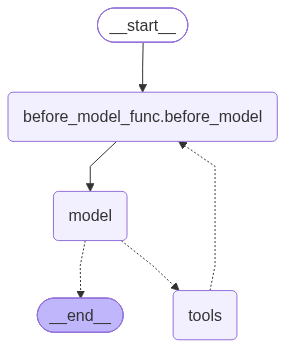

In [11]:
display(Image(data=agent.get_graph().draw_mermaid_png(), format="png"))

# Testground


In [12]:
guest = "Smith"
session_config  = { "configurable": { "thread_id": f"{guest}_2" } }
session_context = { "user_id": guest }

In [13]:
answer_1 = agent.invoke(
    input={
        "messages": [HumanMessage("Hello! My name is Smith and I'm planning a 7-night anniversary trip in late May for my wife and me. "
                "I'm vegetarian, I always need an aisle seat, and we love spending time at the beach.")]
    },
    config=session_config,
    context=session_context
)

[values] {'messages': [HumanMessage(content="Hello! My name is Smith and I'm planning a 7-night anniversary trip in late May for my wife and me. I'm vegetarian, I always need an aisle seat, and we love spending time at the beach.", additional_kwargs={}, response_metadata={}, id='e4a81aeb-ec57-4b25-97b0-db118ca3e623')]}
Event: befor_model; User Id: Smith
{'messages': [HumanMessage(content="Hello! My name is Smith and I'm planning a 7-night anniversary trip in late May for my wife and me. I'm vegetarian, I always need an aisle seat, and we love spending time at the beach.", additional_kwargs={}, response_metadata={}, id='e4a81aeb-ec57-4b25-97b0-db118ca3e623')]}
[updates] {'before_model_func.before_model': None}
[updates] {'model': {'messages': [AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 90, 'prompt_tokens': 542, 'total_tokens': 632, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 're

In [14]:
print_conversation(answer_1['messages'])

================================ Human Message =================================

Hello! My name is Smith and I'm planning a 7-night anniversary trip in late May for my wife and me. I'm vegetarian, I always need an aisle seat, and we love spending time at the beach.
================================== Ai Message ==================================
Tool Calls:
  save_preference (call_y0nFNLs2Ny2SpqJgX9QywwaD)
 Call ID: call_y0nFNLs2Ny2SpqJgX9QywwaD
  Args:
    key: dietary
    preference: vegetarian
  save_preference (call_TI5QPgSwr02LdkwObnzaDd2v)
 Call ID: call_TI5QPgSwr02LdkwObnzaDd2v
  Args:
    key: seat_preference
    preference: aisle seat
  save_preference (call_E6zE7lFYeDeZYO7opI1iLEJ9)
 Call ID: call_E6zE7lFYeDeZYO7opI1iLEJ9
  Args:
    key: favourite_activities
    preference: beach time
================================= Tool Message =================================
Name: save_preference

Ok
================================= Tool Message =================================
Name:

In [15]:
answer_2 = agent.invoke(
    input={
        "messages": [HumanMessage("what is your name?")]
    },
    config=session_config,
    context=session_context
)

[values] {'messages': [HumanMessage(content="Hello! My name is Smith and I'm planning a 7-night anniversary trip in late May for my wife and me. I'm vegetarian, I always need an aisle seat, and we love spending time at the beach.", additional_kwargs={}, response_metadata={}, id='e4a81aeb-ec57-4b25-97b0-db118ca3e623'), AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 90, 'prompt_tokens': 542, 'total_tokens': 632, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5.6-luna', 'system_fingerprint': None, 'id': 'chatcmpl-EIDtkCRc36u7CNOA8iATbVTEc7ktj', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--01a04dd2-7cf2-7d43-8115-5a62967d4c0f-0', tool_calls=[{'name': 's

In [16]:
print_conversation(answer_2['messages'])

================================ Human Message =================================

Hello! My name is Smith and I'm planning a 7-night anniversary trip in late May for my wife and me. I'm vegetarian, I always need an aisle seat, and we love spending time at the beach.
================================== Ai Message ==================================
Tool Calls:
  save_preference (call_y0nFNLs2Ny2SpqJgX9QywwaD)
 Call ID: call_y0nFNLs2Ny2SpqJgX9QywwaD
  Args:
    key: dietary
    preference: vegetarian
  save_preference (call_TI5QPgSwr02LdkwObnzaDd2v)
 Call ID: call_TI5QPgSwr02LdkwObnzaDd2v
  Args:
    key: seat_preference
    preference: aisle seat
  save_preference (call_E6zE7lFYeDeZYO7opI1iLEJ9)
 Call ID: call_E6zE7lFYeDeZYO7opI1iLEJ9
  Args:
    key: favourite_activities
    preference: beach time
================================= Tool Message =================================
Name: save_preference

Ok
================================= Tool Message =================================
Name:

In [17]:
for x in my_checkpointer.list(config={
        "configurable": {
            "thread_id": "talk_1"
        }
    }):
  print(x)